# Creating Designs by Leveraging LangGraph, OpenAI and Gradio UI

## Problem Statement

### Overview
The project aims to build an AI-powered system that converts simple user ideas into high-quality, cinematic visual designs for digital campaigns. The goal is to simplify the creative process by enabling users to generate compelling images using minimal input, while maintaining consistency and quality.

### Sitation
As a designer working in a modern creative agency, there is a growing demand for rapid, scalable, and personalized visual content for marketing campaigns. Traditional design workflows are time-consuming and require significant manual effort, making it difficult to meet fast-paced campaign needs.

### Task
Design and develop an interactive application that:
* Accepts simple user inputs (idea, genre, style)
* Enhances them into detailed prompts
* Generates high-quality images
* Provides an intuitive UI for easy interaction

### Action
* Build a structured workflow using LangGraph to manage the end-to-end pipeline
* Use ChatOpenAI to enhance user inputs into rich cinematic prompts
* Integrate gpt-image-1 for image generation
* Develop a modular pipeline with nodes for prompt enhancement and image generation
* Create an interactive UI using Gradio with structured inputs (idea, genre, style)
* Optimize user experience by reducing input complexity while maintaining output quality

### Result
Jupyter Notebook (IPYNB file) showcasing the innovative potential of integrating OpenAI's API and Gradio UI in the creative design industry. It focuses on generating customized visual content for campaigns to generate high-quality, visually rich images from simple inputs, reduced dependency on manual design workflows and improve consistency and speed of content creation

## Solution

### Overview
The solution is an AI-driven design assistant that combines:
* Prompt engineering (LangChain)
* Workflow orchestration (LangGraph)
* Image generation (OpenAI)
* User interface (Gradio)

It transforms structured user inputs into detailed prompts and generates corresponding images, enabling efficient and scalable content creation.

### Flow
User Input (Idea, Genre, Style) → Enchance Prompt (using gpt-4o-mini) → Generate Images (using gpt-image-1) → Image Retrieval & Processing (Requests, PIL, BytesIO) → Gradio Output

### Step 1 | Setup Environment - Load API Keys from Environment Variables & Import Necessary Libraries

In [133]:
# Load environment variables from .env file

import os
from dotenv import load_dotenv
load_dotenv()

HF_TOKEN = os.getenv("HF_TOKEN")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY")

keys = ["HF_TOKEN", "GROQ_API_KEY", "OPENAI_API_KEY", "GOOGLE_API_KEY", "LANGCHAIN_API_KEY"]

loaded = [k for k in keys if os.getenv(k)]
missing = [k for k in keys if not os.getenv(k)]

print(f"Keys Loaded: {', '.join(loaded) if loaded else 'None'}")
print(f"Keys Missing: {', '.join(missing) if missing else 'None'}")

Keys Loaded: HF_TOKEN, GROQ_API_KEY, OPENAI_API_KEY, GOOGLE_API_KEY, LANGCHAIN_API_KEY
Keys Missing: None


In [135]:
# Import necessary libraries

import openai
from typing import TypedDict, List, Optional
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
#from pydantic import BaseModel, Field
#from langchain_groq import ChatGroq
#from langchain_community.document_loaders import DirectoryLoader, TextLoader, PyPDFLoader
#from langchain_text_splitters import RecursiveCharacterTextSplitter
#from langchain_openai import OpenAIEmbeddings
#from langchain_huggingface import HuggingFaceEmbeddings
#from langchain_community.vectorstores import FAISS
#from langchain_chroma import Chroma
#import shutil
#from rouge_score import rouge_scorer

# UI library
import gradio as gr

# image processing libraries
import requests
from io import BytesIO
from PIL import Image
import PIL.Image as Image
import base64

# To ignore warning during embedding loading!
from transformers import logging
logging.set_verbosity_error()

print("All libraries imported successfully!")

All libraries imported successfully!


### Step 2 | Setup LLM Chain for Prompt Enhancement

In [136]:
llm_prompt = ChatOpenAI(model="gpt-4o-mini")

response_prompt = llm_prompt.invoke("What is the Capital of India?").content
print("LLM Test Response:",response_prompt)

prompt_template = ChatPromptTemplate.from_messages([
    ("system", """
                You are a senior creative director specializing in high-impact visual campaigns.

                Your task is to transform simple user inputs into a detailed, cinematic image generation prompt.

                Guidelines:
                - Use the genre to define the narrative tone and mood
                - Use the style to define visual aesthetics such as lighting, texture, and rendering style
                - Expand the idea into a vivid scene with strong visual storytelling

                Always include:
                - Scene description (environment and subject)
                - Lighting (dramatic, soft, neon, etc.)
                - Mood (tense, emotional, epic, etc.)
                - Camera perspective (wide-angle, close-up, aerial, etc.)
                - Color palette (warm, cool, high contrast, etc.)

                Ensure the output is:
                - Highly descriptive
                - Cinematic and visually rich
                - Suitable for generating a high-quality promotional banner or poster

                Return only the final enhanced prompt.
    """),
    ("user", """
            Idea: {user_input}
            Genre: {genre}
            Style: {style}
    """)
])

chain_enhanced_prompt = prompt_template | llm_prompt | StrOutputParser()
chain_enhanced_prompt

LLM Test Response: The capital of India is New Delhi.


ChatPromptTemplate(input_variables=['genre', 'style', 'user_input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='\n                You are a senior creative director specializing in high-impact visual campaigns.\n\n                Your task is to transform simple user inputs into a detailed, cinematic image generation prompt.\n\n                Guidelines:\n                - Use the genre to define the narrative tone and mood\n                - Use the style to define visual aesthetics such as lighting, texture, and rendering style\n                - Expand the idea into a vivid scene with strong visual storytelling\n\n                Always include:\n                - Scene description (environment and subject)\n                - Lighting (dramatic, soft, neon, etc.)\n                - Mood (tense, emotional, epic, etc.)\n                - Camera perspective (wide-

### Step 3 | Define Graph State

In [137]:
import PIL.Image as Image

class GraphState(TypedDict):
    user_input: str
    genre: str
    style: str
    enhanced_prompt: str
    images: List[Image.Image]
    num_images: int

print("GraphState TypedDict defined successfully!")

GraphState TypedDict defined successfully!


### Step 4 | Define Functions (Node Functions & Helper Function to Generate Image)

In [138]:
# Gnerates Function for returning list of images generated using OpenAI image model
def generate_image(prompt: str, num_images: int = 1):
    """
    Generate images using OpenAI image model and return PIL images.
    
    Args:
        prompt (str): Enhanced prompt for image generation
        num_images (int): Number of images to generate
        size (str): Image size
    
    Returns:
        List[PIL.Image.Image]: List of generated images
    """

    # invoke the OpenAI image generation API & handle error appropriately
    try:
        response = openai.images.generate(
            model="gpt-image-1",
            prompt=prompt,
            size="auto",
            n=num_images
        )
    except Exception as e:
        # Check if it's a safety filter hit, otherwise give a generic error
        msg = "Safety policy violation. Please try a different prompt." if "content_policy" in str(e) else "Service error. Please try again."
        return {"error": msg}

    # Validate response
    if not response:
        raise ValueError("No response from OpenAI image API.")

    url_data = response.data
    if not url_data:
        raise ValueError("No image data returned.")

    images = []

    # Take care of both URL and base64 image data formats and convert to PIL images from bytes (generated from URL or base64)
    for img_data in url_data:
        image_url = getattr(img_data, "url", None)
        b64_json = getattr(img_data, "b64_json", None)

        if image_url:
            img_bytes = requests.get(image_url, timeout=10).content
        elif b64_json:
            img_bytes = base64.b64decode(b64_json)
        else:
            raise ValueError("No valid image data found.")
        
        from PIL import Image
        img = Image.open(BytesIO(img_bytes))
        images.append(img)

    return images

# Node function to enhance the user input prompt using the LLM chain and return the enhanced prompt for image generation
def enhance_prompt_node(state: GraphState):
    enhanced_prompt = chain_enhanced_prompt.invoke({
        "user_input": state.get("user_input", ""),
        "genre": state.get("genre", ""),
        "style": state.get("style", "")
    })
    return {"enhanced_prompt": enhanced_prompt}

# Node function to generate images using the enhanced prompt and return the list of generated images
def generate_image_node(state: GraphState):
    # Read inputs from state
    prompt = state.get("enhanced_prompt")
    num_images = state.get("num_images", 1)

    # Basic validation
    if not prompt:
        raise ValueError("Missing 'enhanced_prompt' in state")

    # Call helper function defined above to generate images using OpenAI image model and return PIL images
    images = generate_image(
        prompt=prompt,
        num_images=num_images
    )

    # Return partial state update with generated images
    return {"images": images}

print("Node functions defined successfully!")

Node functions defined successfully!


### Step 5 | Define Graph

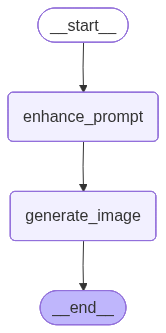

In [139]:
# Initialize the state graph
graph = StateGraph(GraphState)

# Add nodes to the graph
graph.add_node("enhance_prompt", enhance_prompt_node)
graph.add_node("generate_image", generate_image_node)

# Add edges to define the flow
graph.add_edge(START, "enhance_prompt")
graph.add_edge("enhance_prompt", "generate_image")
graph.add_edge("generate_image", END)

# Compile the graph into an executable application
app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

### Step 6 | Define App (Invoke Graph) Pipeline

In [140]:
def run_pipeline(user_input, genre, style, num_images):
    result = app.invoke({
        "user_input": user_input,
        "genre": genre,
        "style": style,
        "enhanced_prompt": "",
        "images": [],
        "num_images": num_images
    })
    return result["images"], result["enhanced_prompt"]

### Step 7 | Build Gradio Interface

In [141]:
with gr.Blocks() as App:

    gr.Markdown("## 🎬 AI Design Assistant")
    gr.Markdown("Generate Customized Visual Content for Campaigns")

    # Fetch the API key
    api_key = os.getenv("OPENAI_API_KEY", "")
    
    # Row 1: Idea (full width)
    with gr.Row():
        user_input = gr.Textbox(
            label="Enter your idea",
            placeholder="e.g., astronaut drifting in space",
            scale=1
        )
        api_key_input = gr.Textbox(label="OpenAI API Key",type="password",value=api_key, placeholder="Enter API key here..." if not api_key else "")

    # Row 2: Genre + Style
    with gr.Row():
        genre = gr.Dropdown(
            ["Sci-Fi", "Romance", "Horror", "Action", "Thriller", "Mystery", "Fantasy", "Adventure", "Drama", "Comedy", "Crime", "Historical", "War", "Superhero", "Cyberpunk", "Post-Apocalyptic", "Noir", "Western"],
            value="Sci-Fi",
            label="Genre"
        )

        style = gr.Dropdown(
            ["Cinematic", "Realistic", "Anime", "Cyberpunk", "Photorealistic", "3D Render", "Illustration", "Digital Art", "Oil Painting", "Watercolor", "Sketch", "Comic Book", "Pixel Art", "Minimalist", "Surreal", "Fantasy Art", "Retro", "Futuristic", "Noir", "Vintage"],
            value="Cinematic",
            label="Style"
        )
        num_images = gr.Slider(1, 4, value=1, step=1, label="Number of Images")

    # Row 3: Controls
    with gr.Row():
        generate_btn = gr.Button("Generate 🚀")

    # Output Section
    with gr.Row():
        with gr.Column():
            output_prompt = gr.Textbox(label="Enhanced Prompt")
            output_gallery = gr.Gallery(label="Generated Images")
            

    # Button Action
    generate_btn.click(
        fn=run_pipeline,
        inputs=[user_input, genre, style, num_images],
        outputs=[output_gallery, output_prompt]
    )

### Step 8 | Launch App

In [146]:
App.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


In [147]:
App.close()

Closing server running on port: 7862
